# Generate EKF C-code from Dynamic System Model

In [2]:
# Generate and Compile C Code
%run generate_ekf.py

import os
import subprocess
import ctypes
import numpy as np
import importlib
importlib.reload(ctypes)
importlib.reload(subprocess)
# Compile C code and create library

# https://cu7ious.medium.com/how-to-use-dynamic-libraries-in-c-46a0f9b98270
path = os.path.abspath('c_code')
# Remove old library
subprocess.call('rm -f *.so', shell=True, cwd=path)
subprocess.call('rm -f *.o', shell=True, cwd=path)
# Compile object files
subprocess.call('gcc -fPIC -c *.c common/*.c -Icommon', shell=True, cwd=path)
# Create library
subprocess.call('gcc -shared -Wl,-soname,libtools.so -o libtools.so *.o', shell=True, cwd=path)
# Remove object files
# subprocess.call('rm *.o', shell=True, cwd=path)

lib_path = os.path.abspath("c_code/libtools.so")
lib = ctypes.CDLL(lib_path)

# define argument types 
lib.ekf_set_Q.argtypes = [ctypes.POINTER(ctypes.c_float)]
lib.ekf_set_R.argtypes = [ctypes.POINTER(ctypes.c_float)]
lib.ekf_set_X.argtypes = [ctypes.POINTER(ctypes.c_float)]
lib.ekf_set_P_diag.argtypes = [ctypes.POINTER(ctypes.c_float)]

lib.ekf_get_X.restype = ctypes.POINTER(ctypes.c_float)
lib.ekf_get_P.restype = ctypes.POINTER(ctypes.c_float)

lib.ekf_predict.argtypes = [ctypes.POINTER(ctypes.c_float), ctypes.c_float]
lib.ekf_update.argtypes = [ctypes.POINTER(ctypes.c_float)]

ekf_use_quat = ctypes.c_bool.in_dll(lib, "ekf_use_quat")

PREDICTION:
CSE
SIMPLIFY
CCODE
S and PHT MATRICES FOR SOLVING K:
CSE
SIMPLIFY
CCODE
UPDATE:
CSE
SIMPLIFY
CCODE


# Test C code

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# IMU
imu_data = pd.read_csv('imu.csv')

imu_t   = imu_data['t_imuRecv_orin']
imu_ax  = imu_data['imu_ax']
imu_ay  = imu_data['imu_ay']
imu_az  = imu_data['imu_az']
imu_p   = imu_data['imu_p']
imu_q   = imu_data['imu_q']
imu_r   = imu_data['imu_r']

# EKF INPUT
U = np.stack([imu_ax, imu_ay, imu_az, imu_p, imu_q, imu_r]).T

# OPTITRACK
opti_data = pd.read_csv('optitrack.csv')

opti_t  = opti_data['t_optiRecv_orin']
opti_x  = opti_data['optitrack_x']
opti_y  = opti_data['optitrack_y']
opti_z  = opti_data['optitrack_z']
opti_qw = opti_data['optitrack_qw']
opti_qx = opti_data['optitrack_qx']
opti_qy = opti_data['optitrack_qy']
opti_qz = opti_data['optitrack_qz']

# EKF MEASUREMENT
Z = np.stack([opti_x, opti_y, opti_z, opti_qw, opti_qx, opti_qy, opti_qz]).T


In [4]:
# INITIALIZE EKF
# initial state X=[x,y,z,vx,vy,vz,qw,qx,qy,qz,bx,by,bz,bp,bq,br]
lenX = 16
X_init = np.array([
    opti_x[0], opti_y[0], opti_z[0],
    0,0,0,
    opti_qw[0],opti_qx[0],opti_qy[0],opti_qz[0],
    0,0,0,0,0,0
])

ekf_use_quat.value = True

# initial covariance
P_init = np.array([1.]*lenX)
P_init[-6:-3] = 1e-2 # set accel bias covariance
P_init[-3:] = 1e-2 # set gyro bias covariance. 
P_init[-3:] *= (ekf_use_quat.value) # do not estimate bias if no heading measurement

# process noise covariance
Q_diag = np.array([0.5, 0.5, 0.5, 0.1, 0.1, 0.1, 1e-4, 1e-4, 1e-4, 1e-5, 1e-5, 1e-5])
Q_diag[-3:] *= (ekf_use_quat.value)

# measurement noise covariance
R_diag = np.array([0.005, 0.005, 0.005, .05, .05, .05, .05])

lib.ekf_set_Q((ctypes.c_float*len(Q_diag))(*Q_diag))
lib.ekf_set_R((ctypes.c_float*len(R_diag))(*R_diag))
lib.ekf_set_X((ctypes.c_float*len(X_init))(*X_init))
lib.ekf_set_P_diag((ctypes.c_float*len(P_init))(*P_init))


# test ekf_get_state
x = lib.ekf_get_X()
x = np.array([x[i] for i in range(lenX)])
print(x)

# RUN EKF
X_ekf = [X_init]
t_ekf = [imu_t[0]]
P_ekf = [np.array([1.])*int(lenX*(lenX+1)/2)]

X_sampled = []
X_delayed = []
X_shift =[]
m_idx =[]

j = 1
for i in range(1, len(opti_t)):
    # PREDICT UNTIL LATEST OPTITRACK MEASUREMENT (opti_t[i])
    while imu_t[j] < opti_t[i]:
        # predict
        lib.ekf_predict(
            (ctypes.c_float*len(U[j]))(*U[j]),
            ctypes.c_float(imu_t[j]-imu_t[j-1])
        )
        # get state
        x = lib.ekf_get_X()
        x = np.array([x[i] for i in range(lenX)])
        X_ekf.append(x)
        t_ekf.append(imu_t[j])
        # increment imu index
        j+=1
    
    # UPDATE
    lib.ekf_update(
        (ctypes.c_float*len(Z[i]))(*Z[i])
    )
    
    # get Pdiag
    P = lib.ekf_get_P()
    P = np.array([P[i] for i in range(int(lenX*(lenX+1)/2))])
    P_ekf.append(P)

t_ekf = np.array(t_ekf)
X_ekf = np.array(X_ekf)

[ 2.99821305 -2.98023367 -0.03027542  0.          0.          0.
  0.71345031  0.00505557  0.006443    0.70065802  0.          0.
  0.          0.          0.          0.        ]


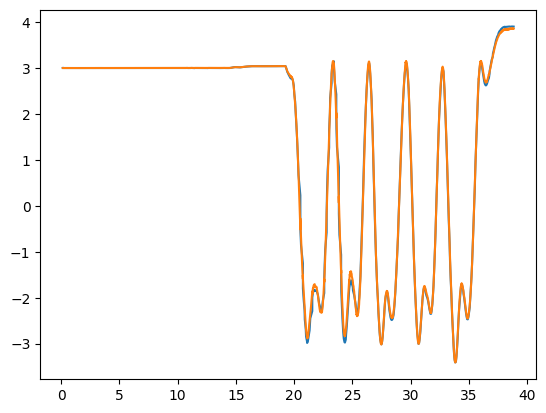

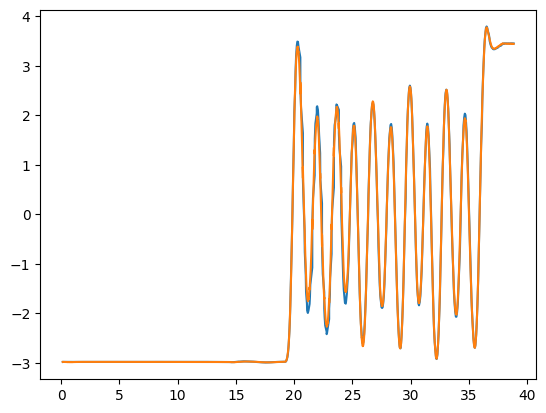

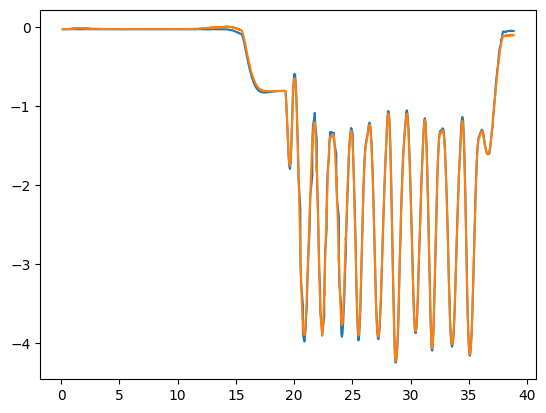

In [5]:
plt.plot(opti_t, opti_x)
plt.plot(t_ekf, X_ekf[:, 0])
plt.show()

plt.plot(opti_t, opti_y)
plt.plot(t_ekf, X_ekf[:, 1])
plt.show()

plt.plot(opti_t, opti_z)
plt.plot(t_ekf, X_ekf[:, 2])
plt.show()